# Causal Discovery on Deep Learning Outputs (4 Segments)

This notebook evaluates various causal discovery algorithms on the hidden states and outputs of an RNN-based deep learning model trained to predict protein-to-RNA ratios (PTRs) from cDNA sequences. 

The dataset contains heavily heterogeneous cDNA sequences. For this experiment, the one-hot-encoded coding sequences (CDS) were processed through a network of 4 unidirectional GRUs. The output was divided into **4 segments of equal lengths**. By calculating the means of these segments alongside sequence length, tissue, and prediction values, we aim to uncover their causal relationships.

In [2]:
import io

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from causallearn.utils.GraphUtils import GraphUtils


In [ ]:
filepath = '../data/processed/rnn_hidden_states_pooled.csv'

In [10]:
all_columns = ['seg1','seg2','seg3','seg4','y_pred','y','len','tissue']

all_rnn_data = pd.read_csv(filepath, names=all_columns)
all_rnn_data

,seg1,seg2,seg3,seg4,y_pred,y,len,tissue
0,0.23858,-0.03204,-0.12674,0.13457,0.58075,1.0,1935.0,20.0
1,-0.44640,0.18358,0.13677,-0.09148,0.35752,1.0,4320.0,10.0
2,0.17260,-0.19898,-0.22365,-0.06009,0.56335,1.0,1719.0,22.0
3,0.18007,-0.15868,-0.08679,0.11612,0.56016,0.0,765.0,7.0
4,0.12154,-0.12210,0.00373,0.17049,0.60807,1.0,4593.0,7.0
...,...,...,...,...,...,...,...,...
19665,0.42271,-0.13956,-0.13820,-0.21124,0.40931,1.0,1074.0,27.0
19666,0.37526,-0.10260,-0.00290,-0.32103,0.31688,0.0,9525.0,27.0
19667,0.25110,0.01716,0.05445,-0.03515,0.47825,1.0,1095.0,23.0
19668,0.33399,-0.02515,-0.00321,-0.31321,0.28183,0.0,2625.0,12.0


In [11]:
columns = ['seg1','seg2','seg3','seg4','y','tissue', 'len']
rnn_data = all_rnn_data[columns]
rnn_data

,seg1,seg2,seg3,seg4,y,tissue,len
0,0.23858,-0.03204,-0.12674,0.13457,1.0,20.0,1935.0
1,-0.44640,0.18358,0.13677,-0.09148,1.0,10.0,4320.0
2,0.17260,-0.19898,-0.22365,-0.06009,1.0,22.0,1719.0
3,0.18007,-0.15868,-0.08679,0.11612,0.0,7.0,765.0
4,0.12154,-0.12210,0.00373,0.17049,1.0,7.0,4593.0
...,...,...,...,...,...,...,...
19665,0.42271,-0.13956,-0.13820,-0.21124,1.0,27.0,1074.0
19666,0.37526,-0.10260,-0.00290,-0.32103,0.0,27.0,9525.0
19667,0.25110,0.01716,0.05445,-0.03515,1.0,23.0,1095.0
19668,0.33399,-0.02515,-0.00321,-0.31321,0.0,12.0,2625.0


---
# LiNGAM

LiNGAM (Linear Non-Gaussian Acyclic Model) assumes linearity in the data, non-Gaussian noise, acyclicity, and no latent common causes. 

We test both:
- **Direct LiNGAM**: Converges easily without needing computational tuning parameters.
- **ICA LiNGAM**: Independent Component Analysis version. As evaluated in the report, ICA LiNGAM proved to be the most consistent algorithm, establishing that the later segments heavily influence the predicted target, whereas segment length and tissue variables naturally map to the bottom of the causal order.

### Direct LiNGAM

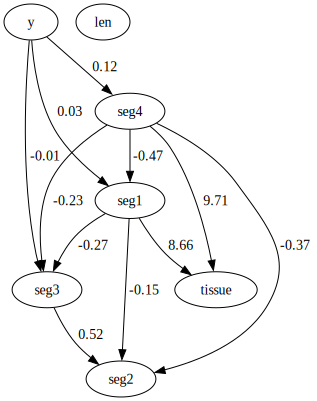

In [8]:
import lingam
from lingam.utils import make_dot,print_causal_directions, print_dagc, make_dot

model = lingam.DirectLiNGAM()
model.fit(rnn_data)

make_dot(model.adjacency_matrix_, labels=columns)

### ICA LINGAM

/home/ttsonev/miniconda3/envs/thesis/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


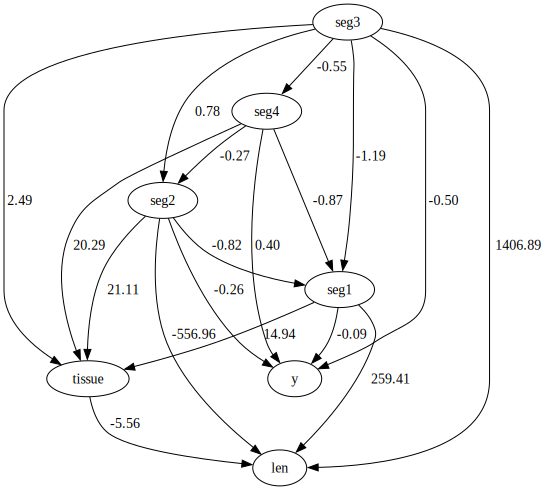

In [9]:
from causallearn.search.FCMBased import lingam
model = lingam.ICALiNGAM(max_iter=1000)
model.fit(rnn_data)

make_dot(model.adjacency_matrix_, labels=columns)

---
# GES

GES (Greedy Equivalence Search) is a score-based algorithm. It searches the graph space by evaluating a Bayesian score as a heuristic, starting from an empty graph. 

The report demonstrated that GES exhibited less consistency across identical setups than ICA LiNGAM, often producing widely varying causal graph distributions.

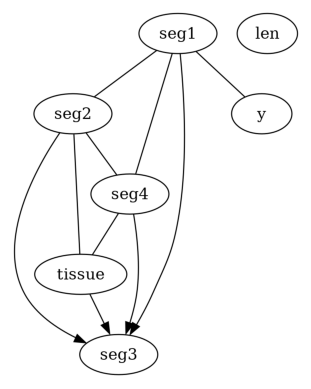

In [212]:
from causallearn.search.ScoreBased.GES import ges
from causallearn.score.LocalScoreFunction import local_score_cv_general

Record = ges(rnn_data)

pyd = GraphUtils.to_pydot(Record['G'], labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')

plt.axis('off')
plt.imshow(img)

---
# FCI 

Fast Causal Inference (FCI) is a constraint-based method. It checks all variables for conditional independence to prune initially fully-connected un-directed edges before heuristically directing them. 

The evaluation revealed that FCI largely detected common latent cause relationships among the RNN segments instead of returning linear causal flows.

In [213]:
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz

graph, edges = fci(rnn_data.to_numpy(), independence_test_method=fisherz, depth=3)

Depth=0, working on node 6: 100%|██████████| 7/7 [00:00<00:00, 636.80it/s]

X2 --> X1
X4 --> X1
X1 --> X5
X6 --> X2
X6 --> X4


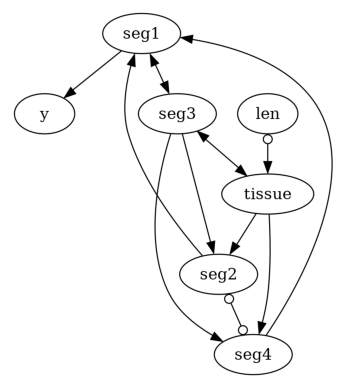

In [214]:
pyd = GraphUtils.to_pydot(graph, labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.axis('off')
plt.imshow(img)


---
# CGNN

Causal Generative Neural Networks (CGNN) learn functional causal models by leveraging neural networks. However, as noted in the report, CGNN often struggled to converge on this deep learning internal state dataset unless provided with a pre-defined skeleton structure.

In [ ]:
# import networkx as nx
# from cdt.causality.graph import CGNN

# obj = CGNN()
# output = obj.predict(rnn_data[:100])   
# nx.draw_networkx(output, font_size=8, with_labels=True)

"\nimport networkx as nx\nfrom cdt.causality.graph import CGNN\n\nobj = CGNN()\noutput = obj.predict(rnn_data[:100])   \nnx.draw_networkx(output, font_size=8, with_labels=True)'\n"

---
# PC

The Peter-Clark (PC) constraint-based algorithm was also considered in the thesis. However, running PC routinely took several hours even on GPU architectures, rendering it highly inefficient compared to GES and LiNGAM for this experimental scale.

In [ ]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

cg = pc(rnn_data.to_numpy(), 0.05, fisherz)
pyd = GraphUtils.to_pydot(cg.G, labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.axis('off')
plt.imshow(img)